# NumPy XP Gold Exercises - Week 5 Day 2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2


## Exercise 1: Advanced Matrix Operations


Exercise 1 - Advanced Matrix Operations:
Creating 5x5 matrix and performing eigenvalue/eigenvector analysis and normalization
--------------------------------------------------------------------------------
Original 5x5 Matrix:
[[  9.96714153   3.61735699  11.47688538  20.23029856   2.65846625]
 [  2.65863043  20.79212816  12.67434729   0.30525614  10.42560044]
 [  0.36582307   0.34270246   7.41962272 -14.13280245 -12.24917833]
 [ -0.62287529  -5.1283112    8.14247333  -4.08024076  -9.12303701]
 [ 19.65648769   2.742237     5.67528205  -9.24748186  -0.44382725]]
Matrix shape: (5, 5)
Matrix dtype: float64

1. Eigenvalue and Eigenvector Analysis:
----------------------------------------
Eigenvalues:
  λ1 = 23.8223
  λ2 = 12.8021+14.3210j
  λ3 = 12.8021-14.3210j
  λ4 = -7.8859+4.2841j
  λ5 = -7.8859-4.2841j

Eigenvectors (each column is an eigenvector):
[[ 0.00494328+0.j         -0.63180271+0.j         -0.63180271-0.j
   0.34134455-0.08103714j  0.34134455+0.08103714j]
 [ 0.94902886+0.j   

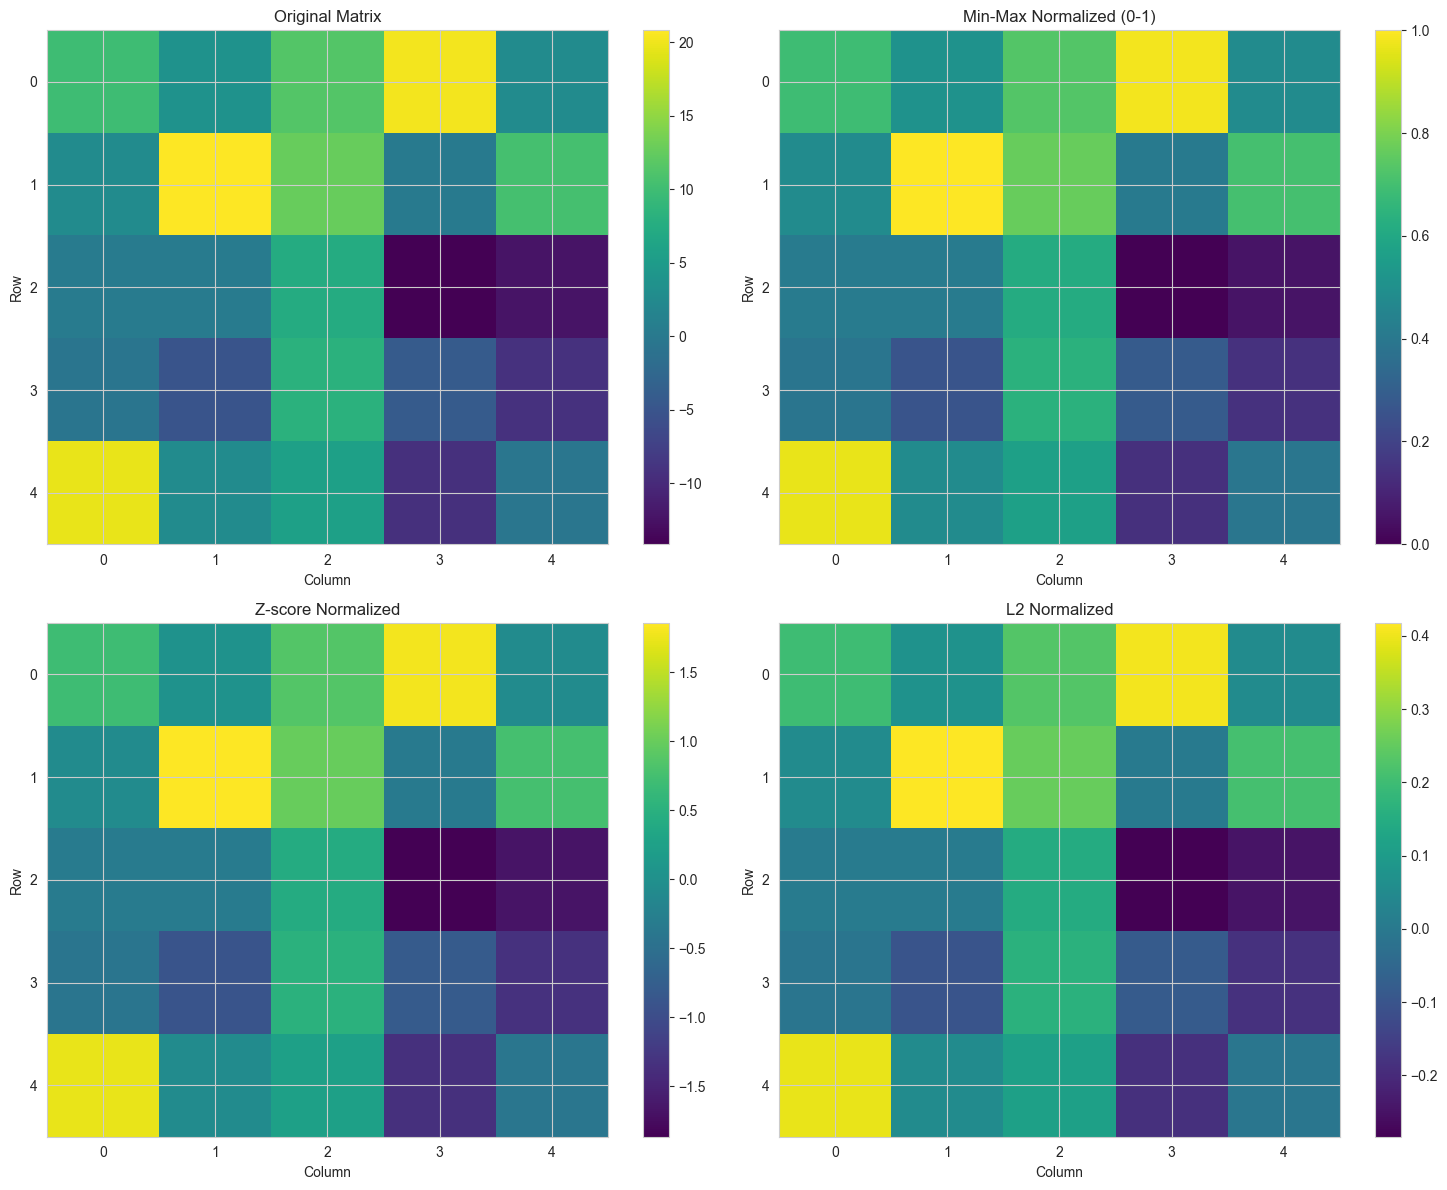


3. Eigenvalue Comparison After Normalization:
--------------------------------------------------
Eigenvalues comparison:
Original matrix: [23.82227883 12.80213506 12.80213506 -7.88586228 -7.88586228]
Min-Max normalized: [ 2.51330449 -0.1588592  -0.1588592   0.39567931  0.39567931]
Z-score normalized: [ 2.0847169   0.90642307  0.90642307 -1.41519608 -0.68661933]

Matrix Properties Summary:
Original - Condition number: 12.9684
Min-Max - Condition number: 34.6666
Z-score - Condition number: 14.0753

Normalization is crucial for machine learning algorithms because:
• It prevents features with larger scales from dominating the distance calculations
• It ensures numerical stability in optimization algorithms
• It helps with convergence in gradient-based algorithms
• It makes different features contribute equally to the analysis


In [2]:
print("Exercise 1 - Advanced Matrix Operations:")
print("Creating 5x5 matrix and performing eigenvalue/eigenvector analysis and normalization")
print("-" * 80)

# Create a 5x5 matrix with random numbers
np.random.seed(42)
matrix_5x5 = np.random.randn(5, 5) * 10 + 5  # Random matrix with mean=5, std=10

print("Original 5x5 Matrix:")
print(matrix_5x5)
print(f"Matrix shape: {matrix_5x5.shape}")
print(f"Matrix dtype: {matrix_5x5.dtype}")

# 1. Calculate eigenvalues and eigenvectors
print(f"\n1. Eigenvalue and Eigenvector Analysis:")
print("-" * 40)

eigenvalues, eigenvectors = np.linalg.eig(matrix_5x5)

print("Eigenvalues:")
for i, eigenval in enumerate(eigenvalues):
    if np.iscomplex(eigenval):
        print(f"  λ{i+1} = {eigenval:.4f}")
    else:
        print(f"  λ{i+1} = {eigenval.real:.4f}")

print(f"\nEigenvectors (each column is an eigenvector):")
print(eigenvectors)

# Find the dominant eigenvalue and eigenvector
dominant_idx = np.argmax(np.abs(eigenvalues))
dominant_eigenvalue = eigenvalues[dominant_idx]
dominant_eigenvector = eigenvectors[:, dominant_idx]

print(f"\nDominant eigenvalue: {dominant_eigenvalue:.4f}")
print(f"Corresponding eigenvector: {dominant_eigenvector}")

# Verify the eigenvalue equation: Av = λv
verification = np.dot(matrix_5x5, dominant_eigenvector)
expected = dominant_eigenvalue * dominant_eigenvector
print(f"\nVerification (Av vs λv):")
print(f"Av = {verification}")
print(f"λv = {expected}")
print(f"Are they equal? {np.allclose(verification, expected)}")

# 2. Matrix Normalization
print(f"\n2. Matrix Normalization:")
print("-" * 40)

# Method 1: Min-Max Normalization (0-1 scaling)
matrix_min = np.min(matrix_5x5)
matrix_max = np.max(matrix_5x5)
matrix_minmax_normalized = (matrix_5x5 - matrix_min) / (matrix_max - matrix_min)

print("Min-Max Normalization (0-1 scaling):")
print(f"Original range: [{matrix_min:.4f}, {matrix_max:.4f}]")
print(f"Normalized range: [{np.min(matrix_minmax_normalized):.4f}, {np.max(matrix_minmax_normalized):.4f}]")
print("Normalized matrix:")
print(matrix_minmax_normalized)

# Method 2: Z-score Normalization (standardization)
matrix_mean = np.mean(matrix_5x5)
matrix_std = np.std(matrix_5x5)
matrix_zscore_normalized = (matrix_5x5 - matrix_mean) / matrix_std

print(f"\nZ-score Normalization (standardization):")
print(f"Original mean: {matrix_mean:.4f}, std: {matrix_std:.4f}")
print(f"Normalized mean: {np.mean(matrix_zscore_normalized):.4f}, std: {np.std(matrix_zscore_normalized):.4f}")
print("Normalized matrix:")
print(matrix_zscore_normalized)

# Method 3: L2 Normalization (unit vector scaling)
matrix_l2_norm = np.linalg.norm(matrix_5x5)
matrix_l2_normalized = matrix_5x5 / matrix_l2_norm

print(f"\nL2 Normalization (unit vector scaling):")
print(f"Original L2 norm: {matrix_l2_norm:.4f}")
print(f"Normalized L2 norm: {np.linalg.norm(matrix_l2_normalized):.4f}")
print("Normalized matrix:")
print(matrix_l2_normalized)

# Visualizing the matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Original matrix
im1 = axes[0, 0].imshow(matrix_5x5, cmap='viridis', aspect='auto')
axes[0, 0].set_title('Original Matrix')
axes[0, 0].set_xlabel('Column')
axes[0, 0].set_ylabel('Row')
plt.colorbar(im1, ax=axes[0, 0])

# Min-Max normalized
im2 = axes[0, 1].imshow(matrix_minmax_normalized, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Min-Max Normalized (0-1)')
axes[0, 1].set_xlabel('Column')
axes[0, 1].set_ylabel('Row')
plt.colorbar(im2, ax=axes[0, 1])

# Z-score normalized
im3 = axes[1, 0].imshow(matrix_zscore_normalized, cmap='viridis', aspect='auto')
axes[1, 0].set_title('Z-score Normalized')
axes[1, 0].set_xlabel('Column')
axes[1, 0].set_ylabel('Row')
plt.colorbar(im3, ax=axes[1, 0])

# L2 normalized
im4 = axes[1, 1].imshow(matrix_l2_normalized, cmap='viridis', aspect='auto')
axes[1, 1].set_title('L2 Normalized')
axes[1, 1].set_xlabel('Column')
axes[1, 1].set_ylabel('Row')
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# Compare eigenvalues of original vs normalized matrices
print(f"\n3. Eigenvalue Comparison After Normalization:")
print("-" * 50)

eigenvals_original = np.linalg.eigvals(matrix_5x5)
eigenvals_minmax = np.linalg.eigvals(matrix_minmax_normalized)
eigenvals_zscore = np.linalg.eigvals(matrix_zscore_normalized)

print("Eigenvalues comparison:")
print(f"Original matrix: {eigenvals_original.real}")
print(f"Min-Max normalized: {eigenvals_minmax.real}")
print(f"Z-score normalized: {eigenvals_zscore.real}")

print(f"\nMatrix Properties Summary:")
print(f"Original - Condition number: {np.linalg.cond(matrix_5x5):.4f}")
print(f"Min-Max - Condition number: {np.linalg.cond(matrix_minmax_normalized):.4f}")
print(f"Z-score - Condition number: {np.linalg.cond(matrix_zscore_normalized):.4f}")

print(f"\nNormalization is crucial for machine learning algorithms because:")
print("• It prevents features with larger scales from dominating the distance calculations")
print("• It ensures numerical stability in optimization algorithms")
print("• It helps with convergence in gradient-based algorithms")
print("• It makes different features contribute equally to the analysis")

## Exercise 2: Statistical Distribution Analysis



Exercise 2 - Statistical Distribution Analysis:
Generating normal distribution and analyzing skewness and kurtosis
----------------------------------------------------------------------
Generated Datasets:
Normal Distribution: 1000 data points
Right-Skewed (Exponential): 1000 data points
Left-Skewed: 1000 data points
High Kurtosis (Laplace): 1000 data points
Low Kurtosis (Uniform): 1000 data points

Statistical Analysis:
--------------------------------------------------

Normal Distribution:
  Mean: 49.75
  Median: 49.61
  Standard Deviation: 15.69
  Skewness: 0.132
  Kurtosis: 0.218
  Interpretation: approximately symmetric, normal kurtosis (mesokurtic)

Right-Skewed (Exponential):
  Mean: 48.34
  Median: 42.73
  Standard Deviation: 18.37
  Skewness: 1.939
  Kurtosis: 5.274
  Interpretation: right-skewed (positive skew), high kurtosis (leptokurtic) - heavy tails

Left-Skewed:
  Mean: 79.59
  Median: 85.24
  Standard Deviation: 20.13
  Skewness: -1.923
  Kurtosis: 5.223
  Interpretati

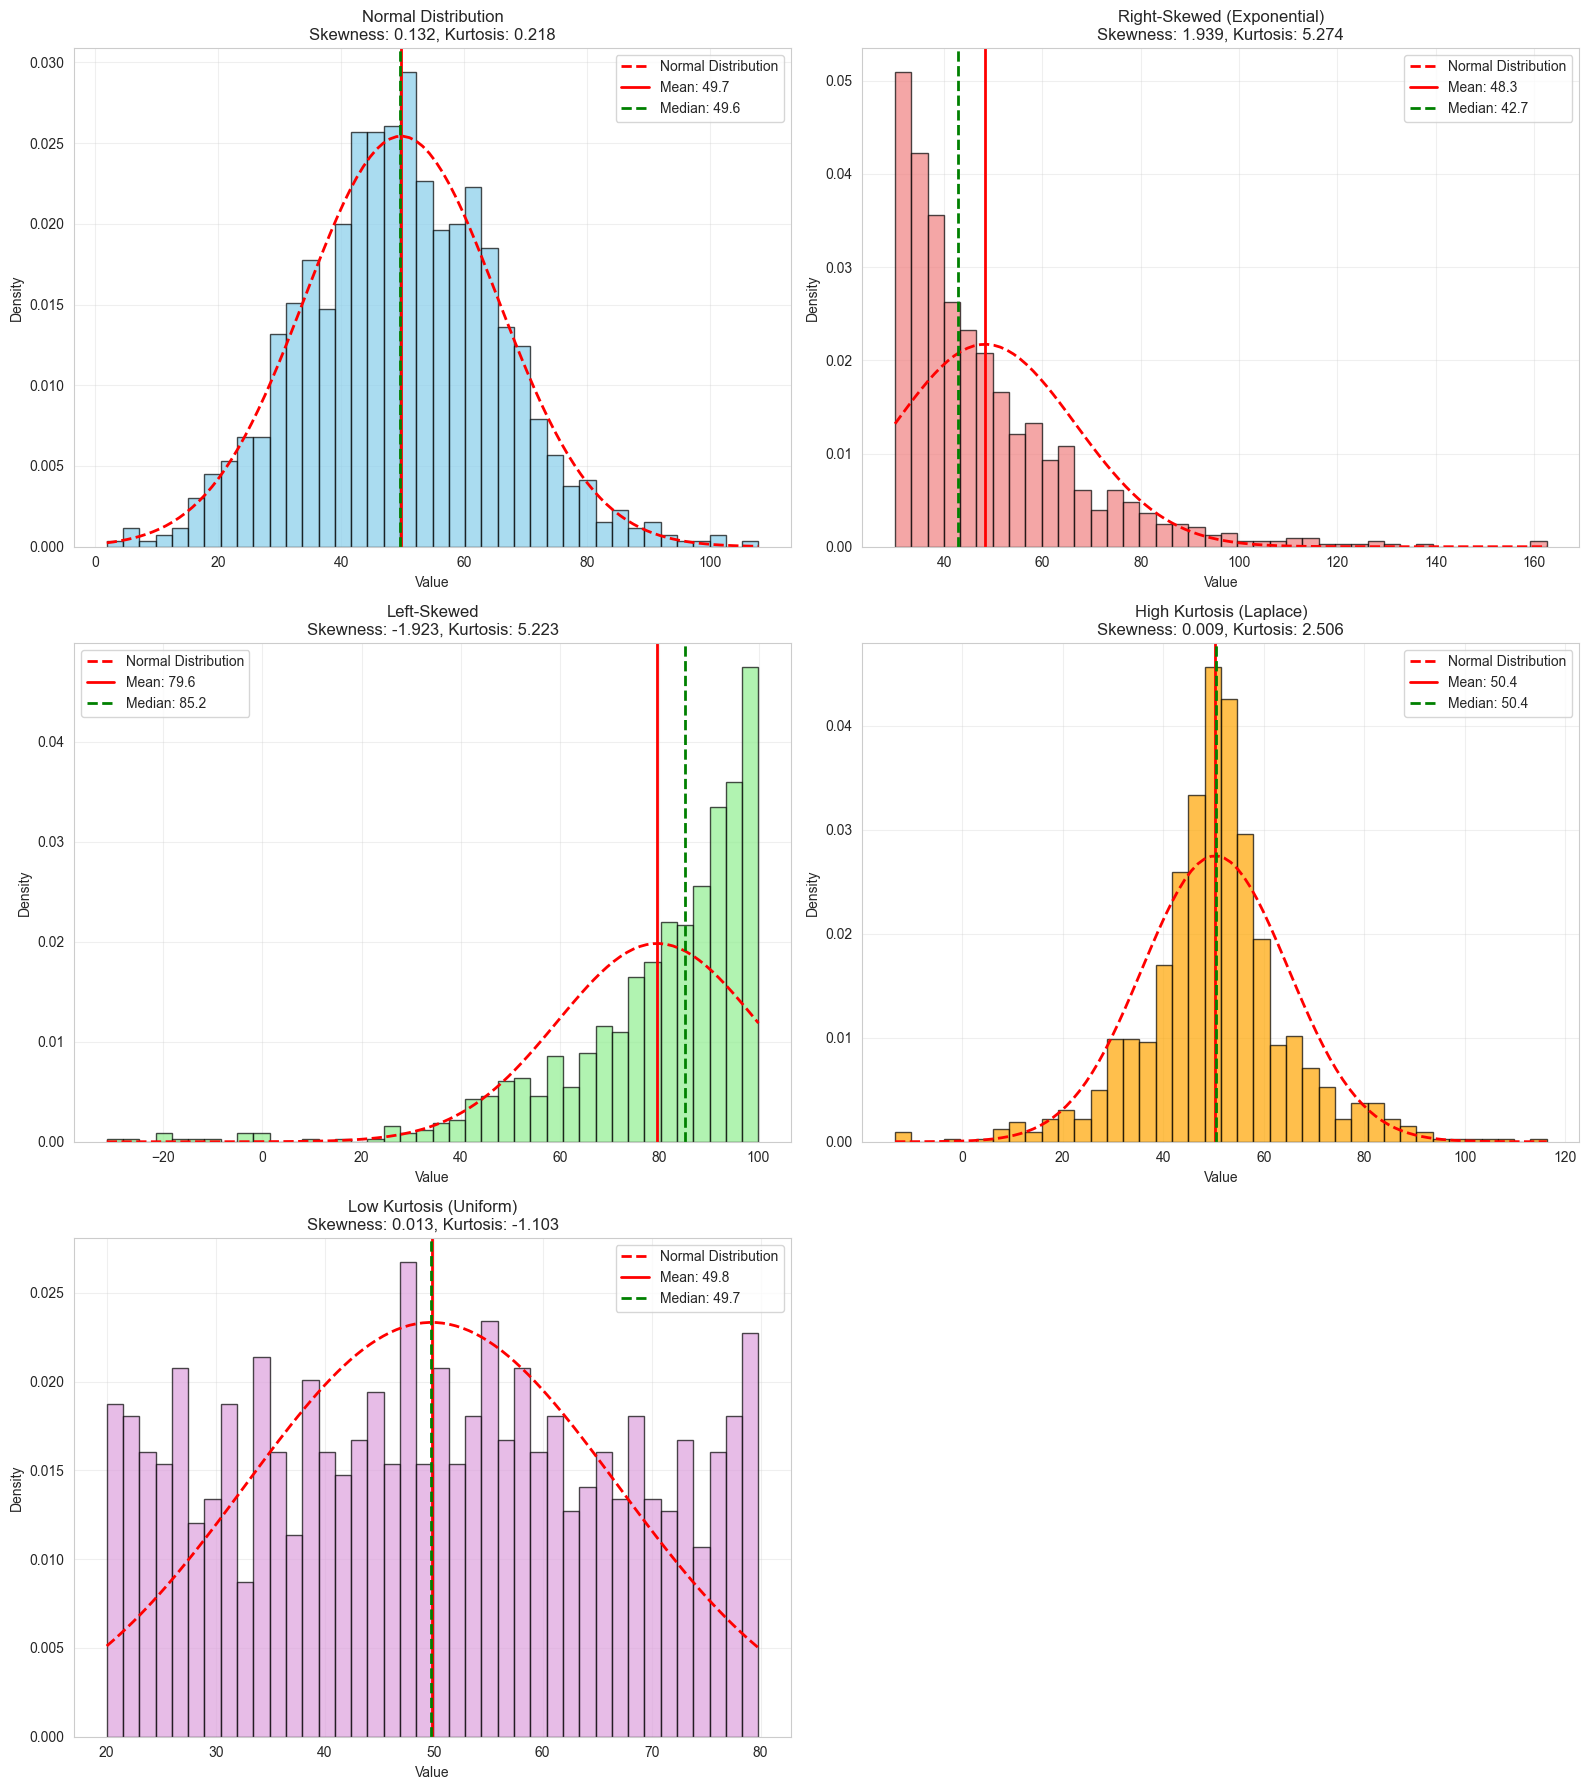

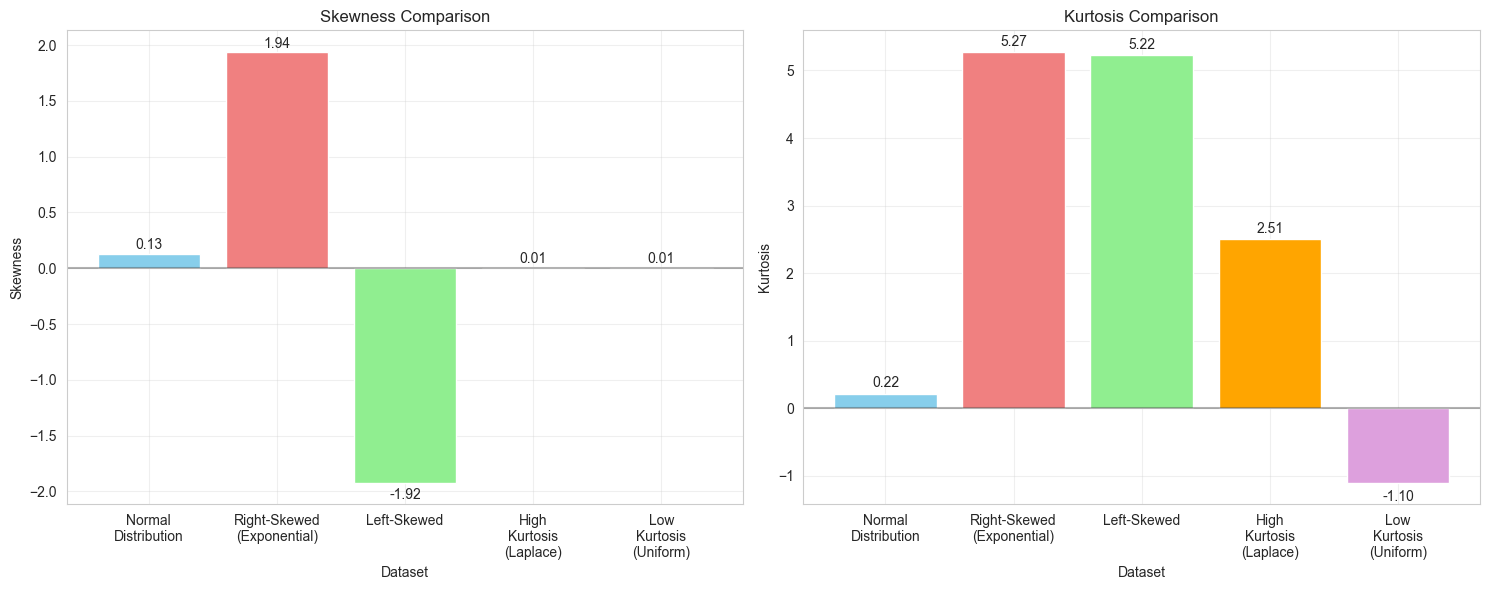


SUMMARY TABLE - Statistical Measures
                   Dataset   Mean  Median    Std  Skewness  Kurtosis
       Normal Distribution 49.748  49.606 15.688     0.132     0.218
Right-Skewed (Exponential) 48.339  42.731 18.365     1.939     5.274
               Left-Skewed 79.589  85.245 20.130    -1.923     5.223
   High Kurtosis (Laplace) 50.359  50.437 14.518     0.009     2.506
    Low Kurtosis (Uniform) 49.804  49.744 17.100     0.013    -1.103

KEY INTERPRETATIONS:
SKEWNESS:
• Skewness = 0: Perfectly symmetric distribution
• Skewness > 0: Right-skewed (tail extends to the right)
• Skewness < 0: Left-skewed (tail extends to the left)
• |Skewness| < 0.5: Approximately symmetric
• |Skewness| > 1: Highly skewed

KURTOSIS:
• Kurtosis = 0: Normal distribution (mesokurtic)
• Kurtosis > 0: Heavy tails, peaked center (leptokurtic)
• Kurtosis < 0: Light tails, flat center (platykurtic)
• High kurtosis indicates more extreme outliers
• Low kurtosis indicates fewer extreme outliers

PRACTICAL 

In [3]:
print("Exercise 2 - Statistical Distribution Analysis:")
print("Generating normal distribution and analyzing skewness and kurtosis")
print("-" * 70)

# Generate datasets with different statistical properties
np.random.seed(100)

# Dataset 1: Perfect normal distribution
normal_data = np.random.normal(loc=50, scale=15, size=1000)

# Dataset 2: Right-skewed distribution 
right_skewed_data = np.random.exponential(scale=20, size=1000) + 30

# Dataset 3: Left-skewed distribution
left_skewed_data = 100 - np.random.exponential(scale=20, size=1000)

# Dataset 4: High kurtosis (heavy tails)
high_kurtosis_data = np.random.laplace(loc=50, scale=10, size=1000)

# Dataset 5: Low kurtosis (light tails) 
low_kurtosis_data = np.random.uniform(low=20, high=80, size=1000)

datasets = {
    'Normal Distribution': normal_data,
    'Right-Skewed (Exponential)': right_skewed_data,
    'Left-Skewed': left_skewed_data,
    'High Kurtosis (Laplace)': high_kurtosis_data,
    'Low Kurtosis (Uniform)': low_kurtosis_data
}

print("Generated Datasets:")
for name, data in datasets.items():
    print(f"{name}: {len(data)} data points")

# Calculate statistics for each dataset
print(f"\nStatistical Analysis:")
print("-" * 50)

statistics_summary = []

for name, data in datasets.items():
    # Basic statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)
    
    # Skewness and Kurtosis
    skewness = stats.skew(data)
    kurtosis_val = stats.kurtosis(data)
    
    # Store for summary table
    statistics_summary.append({
        'Dataset': name,
        'Mean': mean_val,
        'Median': median_val,
        'Std': std_val,
        'Skewness': skewness,
        'Kurtosis': kurtosis_val
    })
    
    print(f"\n{name}:")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Standard Deviation: {std_val:.2f}")
    print(f"  Skewness: {skewness:.3f}")
    print(f"  Kurtosis: {kurtosis_val:.3f}")
    
    # Interpret skewness
    if abs(skewness) < 0.5:
        skew_interpretation = "approximately symmetric"
    elif skewness > 0.5:
        skew_interpretation = "right-skewed (positive skew)"
    else:
        skew_interpretation = "left-skewed (negative skew)"
    
    # Interpret kurtosis
    if abs(kurtosis_val) < 0.5:
        kurt_interpretation = "normal kurtosis (mesokurtic)"
    elif kurtosis_val > 0.5:
        kurt_interpretation = "high kurtosis (leptokurtic) - heavy tails"
    else:
        kurt_interpretation = "low kurtosis (platykurtic) - light tails"
    
    print(f"  Interpretation: {skew_interpretation}, {kurt_interpretation}")

# Create comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'plum']

for i, (name, data) in enumerate(datasets.items()):
    if i < len(axes):
        # Histogram with density curve
        axes[i].hist(data, bins=40, density=True, alpha=0.7, color=colors[i], edgecolor='black')
        
        #  normal distribution overlay for comparison
        x_range = np.linspace(data.min(), data.max(), 100)
        normal_overlay = stats.norm.pdf(x_range, np.mean(data), np.std(data))
        axes[i].plot(x_range, normal_overlay, 'r--', linewidth=2, label='Normal Distribution')
        
        #  mean and median lines
        axes[i].axvline(np.mean(data), color='red', linestyle='-', linewidth=2, label=f'Mean: {np.mean(data):.1f}')
        axes[i].axvline(np.median(data), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(data):.1f}')
        
        axes[i].set_title(f'{name}\nSkewness: {stats.skew(data):.3f}, Kurtosis: {stats.kurtosis(data):.3f}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove the last subplot if there are 6 subplots but only 5 datasets
if len(datasets) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#  summary comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Skewness comparison
dataset_names = [stats['Dataset'] for stats in statistics_summary]
skewness_values = [stats['Skewness'] for stats in statistics_summary]
kurtosis_values = [stats['Kurtosis'] for stats in statistics_summary]

bars1 = ax1.bar(range(len(dataset_names)), skewness_values, color=colors)
ax1.set_title('Skewness Comparison')
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Skewness')
ax1.set_xticks(range(len(dataset_names)))
ax1.set_xticklabels([name.replace(' ', '\n') for name in dataset_names], rotation=0, ha='center')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars1, skewness_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01 if height > 0 else height - 0.05,
             f'{value:.2f}', ha='center', va='bottom' if height > 0 else 'top')

# Kurtosis comparison
bars2 = ax2.bar(range(len(dataset_names)), kurtosis_values, color=colors)
ax2.set_title('Kurtosis Comparison')
ax2.set_xlabel('Dataset')
ax2.set_ylabel('Kurtosis')
ax2.set_xticks(range(len(dataset_names)))
ax2.set_xticklabels([name.replace(' ', '\n') for name in dataset_names], rotation=0, ha='center')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars2, kurtosis_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05 if height > 0 else height - 0.1,
             f'{value:.2f}', ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

# Summary table
print(f"\n" + "="*70)
print("SUMMARY TABLE - Statistical Measures")
print("="*70)
df_summary = pd.DataFrame(statistics_summary)
df_summary = df_summary.round(3)
print(df_summary.to_string(index=False))

print(f"\nKEY INTERPRETATIONS:")
print("="*50)
print("SKEWNESS:")
print("• Skewness = 0: Perfectly symmetric distribution")
print("• Skewness > 0: Right-skewed (tail extends to the right)")
print("• Skewness < 0: Left-skewed (tail extends to the left)")
print("• |Skewness| < 0.5: Approximately symmetric")
print("• |Skewness| > 1: Highly skewed")

print(f"\nKURTOSIS:")
print("• Kurtosis = 0: Normal distribution (mesokurtic)")
print("• Kurtosis > 0: Heavy tails, peaked center (leptokurtic)")
print("• Kurtosis < 0: Light tails, flat center (platykurtic)")
print("• High kurtosis indicates more extreme outliers")
print("• Low kurtosis indicates fewer extreme outliers")

print(f"\nPRACTICAL APPLICATIONS:")
print("• Financial data: Often shows high kurtosis (fat tails)")
print("• Quality control: Skewness indicates process bias")
print("• Machine learning: Understanding data distribution helps choose appropriate algorithms")
print("• Risk analysis: Kurtosis helps assess tail risk")

## Exercise 3: Time Series Forecasting


Exercise 3 - Time Series Forecasting:
Using linear regression to forecast future sales data
------------------------------------------------------------
Original Monthly Sales Data:
Jan: 328 units
Feb: 125 units
Mar: 406 units
Apr: 456 units
May: 352 units
Jun: 242 units
Jul: 457 units
Aug: 192 units
Sep: 350 units
Oct: 461 units
Nov: 332 units
Dec: 204 units
Total annual sales: 3905 units
Average monthly sales: 325.4 units

Time Series Analysis:
------------------------------
Linear trend equation: Sales = 0.31 * Month + 323.39
R-squared (NumPy): 0.0001
Linear regression coefficient (sklearn): 0.31
Linear regression intercept (sklearn): 323.39
R-squared (sklearn): 0.0001

Forecasted Sales for Next 6 Months:
----------------------------------------
Jan+1 (Month 13): 327 units
Feb+1 (Month 14): 328 units
Mar+1 (Month 15): 328 units
Apr+1 (Month 16): 328 units
May+1 (Month 17): 329 units
Jun+1 (Month 18): 329 units

Prediction Accuracy Metrics:
-----------------------------------
Mean Sq

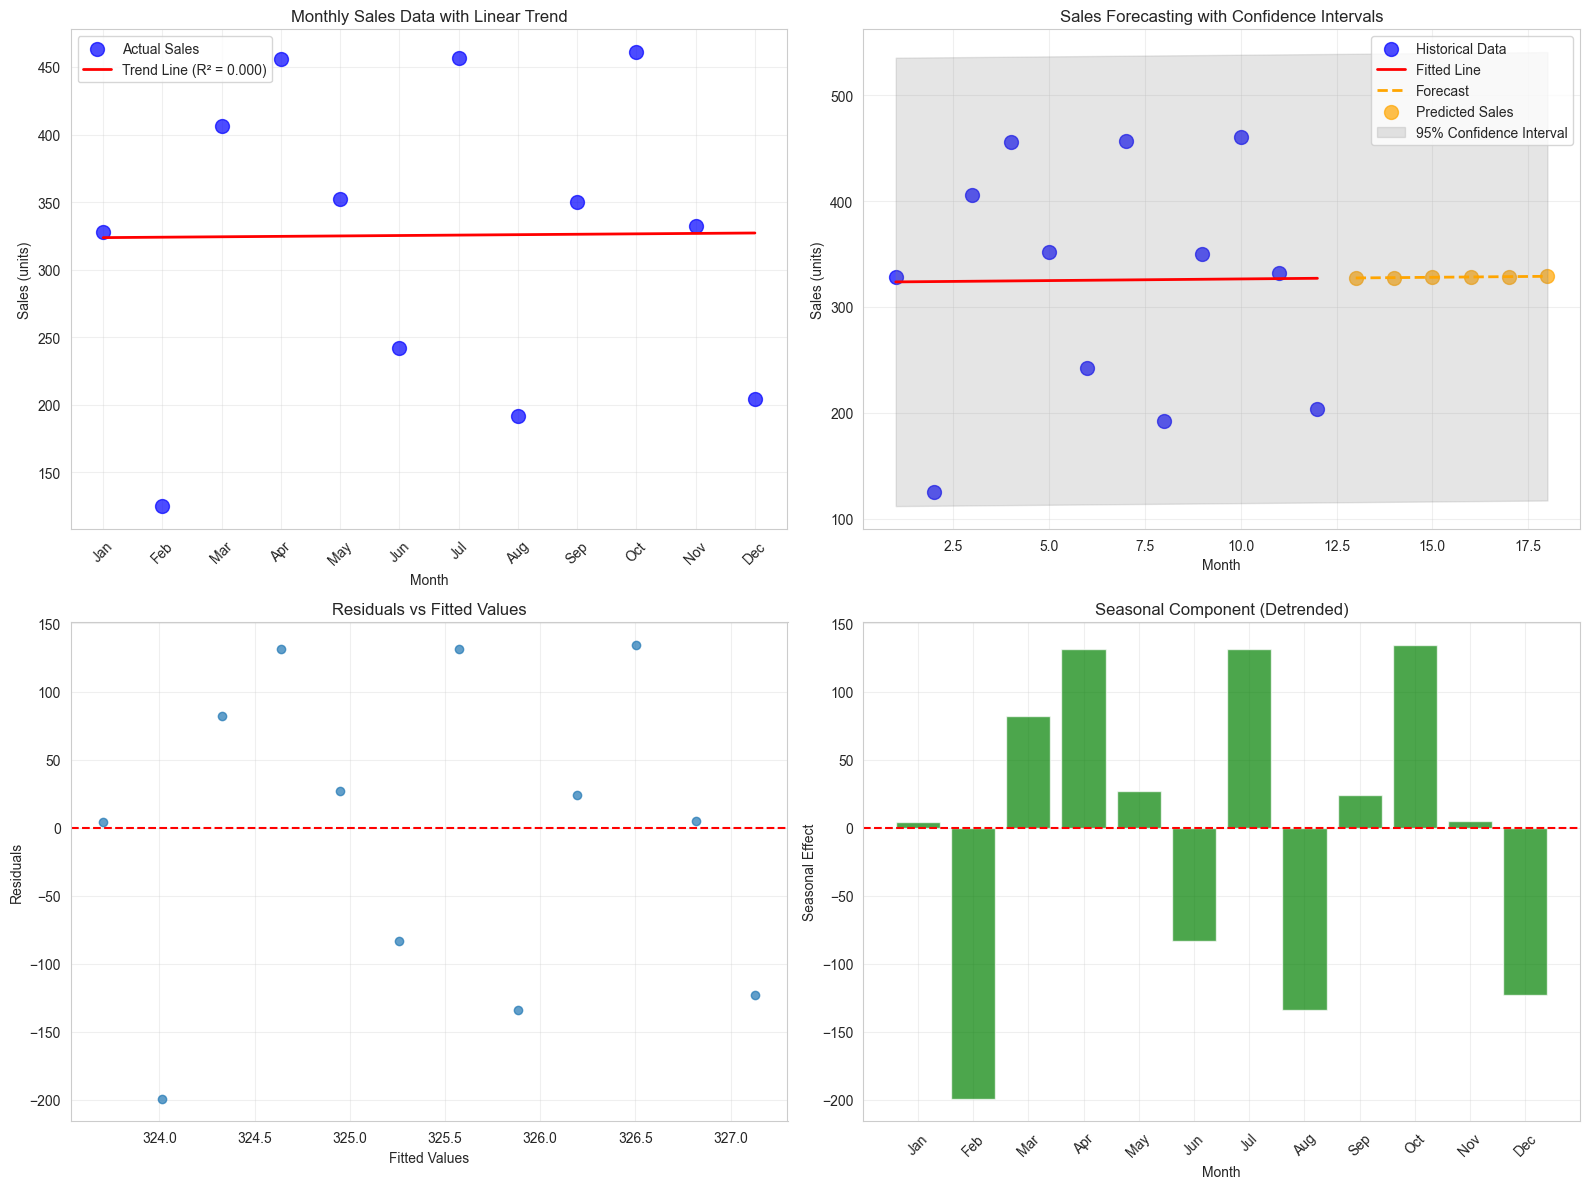


Advanced Time Series Analysis:
----------------------------------------
3-Month Moving Average:
Mar: 286.3 units
Apr: 329.0 units
May: 404.7 units
Jun: 350.0 units
Jul: 350.3 units
Aug: 297.0 units
Sep: 333.0 units
Oct: 334.3 units
Nov: 381.0 units
Dec: 332.3 units

Trend Analysis:
First half average: 318.2 units
Second half average: 332.7 units
Overall trend: increasing by 14.5 units

Model Validation:
--------------------
Slope significance: Not significant
Trend strength: Weak

Forecast Summary Table:
------------------------------
Month  Predicted_Sales  Lower_95%  Upper_95%
Jan+1              327        116        539
Feb+1              328        116        540
Mar+1              328        116        540
Apr+1              328        116        540
May+1              329        117        541
Jun+1              329        117        541

Key Insights:
• Linear regression provides a simple baseline for forecasting
• R-squared indicates how well the trend explains the variation
•

In [4]:
print("Exercise 3 - Time Series Forecasting:")
print("Using linear regression to forecast future sales data")
print("-" * 60)

# Generate monthly sales data as provided
np.random.seed(150)
monthly_sales_data = np.random.randint(100, 500, size=12)  # Random sales data for 12 months

print("Original Monthly Sales Data:")
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, (month, sales) in enumerate(zip(months, monthly_sales_data)):
    print(f"{month}: {sales} units")

print(f"Total annual sales: {np.sum(monthly_sales_data)} units")
print(f"Average monthly sales: {np.mean(monthly_sales_data):.1f} units")

# Prepare data for linear regression
X = np.arange(1, 13).reshape(-1, 1)  # Month numbers (1-12)
y = monthly_sales_data.reshape(-1, 1)  # Sales data

print(f"\nTime Series Analysis:")
print("-" * 30)

# Method 1: Using NumPy polyfit for simple linear regression
coefficients = np.polyfit(X.flatten(), y.flatten(), 1)  # Linear fit (degree=1)
slope, intercept = coefficients
print(f"Linear trend equation: Sales = {slope:.2f} * Month + {intercept:.2f}")

# Calculate R-squared manually
y_pred_numpy = slope * X.flatten() + intercept
ss_res = np.sum((y.flatten() - y_pred_numpy) ** 2)
ss_tot = np.sum((y.flatten() - np.mean(y)) ** 2)
r_squared_numpy = 1 - (ss_res / ss_tot)
print(f"R-squared (NumPy): {r_squared_numpy:.4f}")

# Method 2: Using sklearn for comparison and more detailed analysis
model = LinearRegression()
model.fit(X, y)

y_pred_sklearn = model.predict(X)
r_squared_sklearn = model.score(X, y)

print(f"Linear regression coefficient (sklearn): {model.coef_[0][0]:.2f}")
print(f"Linear regression intercept (sklearn): {model.intercept_[0]:.2f}")
print(f"R-squared (sklearn): {r_squared_sklearn:.4f}")

# Forecast future months (next 6 months)
future_months = np.arange(13, 19).reshape(-1, 1)  # Months 13-18
future_predictions = model.predict(future_months)

print(f"\nForecasted Sales for Next 6 Months:")
print("-" * 40)
future_month_names = ['Jan+1', 'Feb+1', 'Mar+1', 'Apr+1', 'May+1', 'Jun+1']

for i, (month_name, prediction) in enumerate(zip(future_month_names, future_predictions.flatten())):
    print(f"{month_name} (Month {13+i}): {prediction:.0f} units")

# Calculate prediction intervals
residuals = y.flatten() - y_pred_sklearn.flatten()
mse = np.mean(residuals**2)
std_error = np.sqrt(mse)

print(f"\nPrediction Accuracy Metrics:")
print("-" * 35)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.2f}")
print(f"Standard Error: {std_error:.2f}")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Original data with trend line
axes[0, 0].scatter(X, y, color='blue', s=100, alpha=0.7, label='Actual Sales')
axes[0, 0].plot(X, y_pred_sklearn, color='red', linewidth=2, label=f'Trend Line (R² = {r_squared_sklearn:.3f})')
axes[0, 0].set_title('Monthly Sales Data with Linear Trend')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Sales (units)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Forecasting
all_months = np.arange(1, 19)
all_predictions = model.predict(all_months.reshape(-1, 1))

axes[0, 1].scatter(X, y, color='blue', s=100, alpha=0.7, label='Historical Data')
axes[0, 1].plot(all_months[:12], all_predictions[:12], color='red', linewidth=2, label='Fitted Line')
axes[0, 1].plot(all_months[12:], all_predictions[12:], color='orange', linewidth=2, linestyle='--', label='Forecast')
axes[0, 1].scatter(future_months, future_predictions, color='orange', s=100, alpha=0.7, label='Predicted Sales')

# Add confidence intervals
upper_bound = all_predictions.flatten() + 1.96 * std_error
lower_bound = all_predictions.flatten() - 1.96 * std_error
axes[0, 1].fill_between(all_months, upper_bound, lower_bound, alpha=0.2, color='gray', label='95% Confidence Interval')

axes[0, 1].set_title('Sales Forecasting with Confidence Intervals')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales (units)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals analysis
axes[1, 0].scatter(y_pred_sklearn, residuals, alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Residuals vs Fitted Values')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Seasonal decomposition visualization
monthly_avg = np.mean(monthly_sales_data)
detrended = monthly_sales_data - y_pred_numpy
seasonal_component = detrended - np.mean(detrended)

axes[1, 1].bar(months, seasonal_component, alpha=0.7, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Seasonal Component (Detrended)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Seasonal Effect')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  analysis: Moving averages and trend detection
print(f"\nAdvanced Time Series Analysis:")
print("-" * 40)

# Calculate moving averages
window_size = 3
moving_avg = np.convolve(monthly_sales_data, np.ones(window_size)/window_size, mode='valid')

print(f"3-Month Moving Average:")
for i, (month, ma_value) in enumerate(zip(months[window_size-1:], moving_avg)):
    print(f"{month}: {ma_value:.1f} units")

# Trend detection
first_half = np.mean(monthly_sales_data[:6])
second_half = np.mean(monthly_sales_data[6:])
trend_direction = "increasing" if second_half > first_half else "decreasing"

print(f"\nTrend Analysis:")
print(f"First half average: {first_half:.1f} units")
print(f"Second half average: {second_half:.1f} units")
print(f"Overall trend: {trend_direction} by {abs(second_half - first_half):.1f} units")

# Model validation metrics
print(f"\nModel Validation:")
print("-" * 20)
print(f"Slope significance: {'Significant' if abs(slope) > std_error else 'Not significant'}")
print(f"Trend strength: {'Strong' if r_squared_sklearn > 0.7 else 'Moderate' if r_squared_sklearn > 0.4 else 'Weak'}")

#  summary table
forecast_summary = pd.DataFrame({
    'Month': future_month_names,
    'Predicted_Sales': future_predictions.flatten().round(0).astype(int),
    'Lower_95%': (future_predictions.flatten() - 1.96 * std_error).round(0).astype(int),
    'Upper_95%': (future_predictions.flatten() + 1.96 * std_error).round(0).astype(int)
})

print(f"\nForecast Summary Table:")
print("-" * 30)
print(forecast_summary.to_string(index=False))

print(f"\nKey Insights:")
print("• Linear regression provides a simple baseline for forecasting")
print("• R-squared indicates how well the trend explains the variation")
print("• Confidence intervals show prediction uncertainty")
print("• Consider seasonality and external factors for better accuracy")
print("• More advanced methods (ARIMA, exponential smoothing) may be needed for complex patterns")

## Exercise 4: Pandas Data Aggregation



Exercise 4 - Pandas Data Aggregation:
Advanced grouping and aggregation techniques
--------------------------------------------------
Original DataFrame:
     Product  Sales     Month
0  Product A    200   January
1  Product B    150  February
2  Product C    300     March
3  Product A    250     April
4  Product B    180       May
DataFrame shape: (5, 3)

Expanded DataFrame for comprehensive analysis:
Shape: (100, 8)
     Product  Sales     Month Region Salesperson  Cost  Profit  Profit_Margin
0  Product C    270  February   East       Diana    54     216      80.000000
1  Product B    218     April   East         Bob   224      -6      -2.752294
2  Product A    170      June  South       Diana   299    -129     -75.882353
3  Product E    362     March  North         Eve   238     124      34.254144
4  Product C    449  February   East         Bob   108     341      75.946548
5  Product E    146  February   East       Diana   249    -103     -70.547945
6  Product B    195     April   

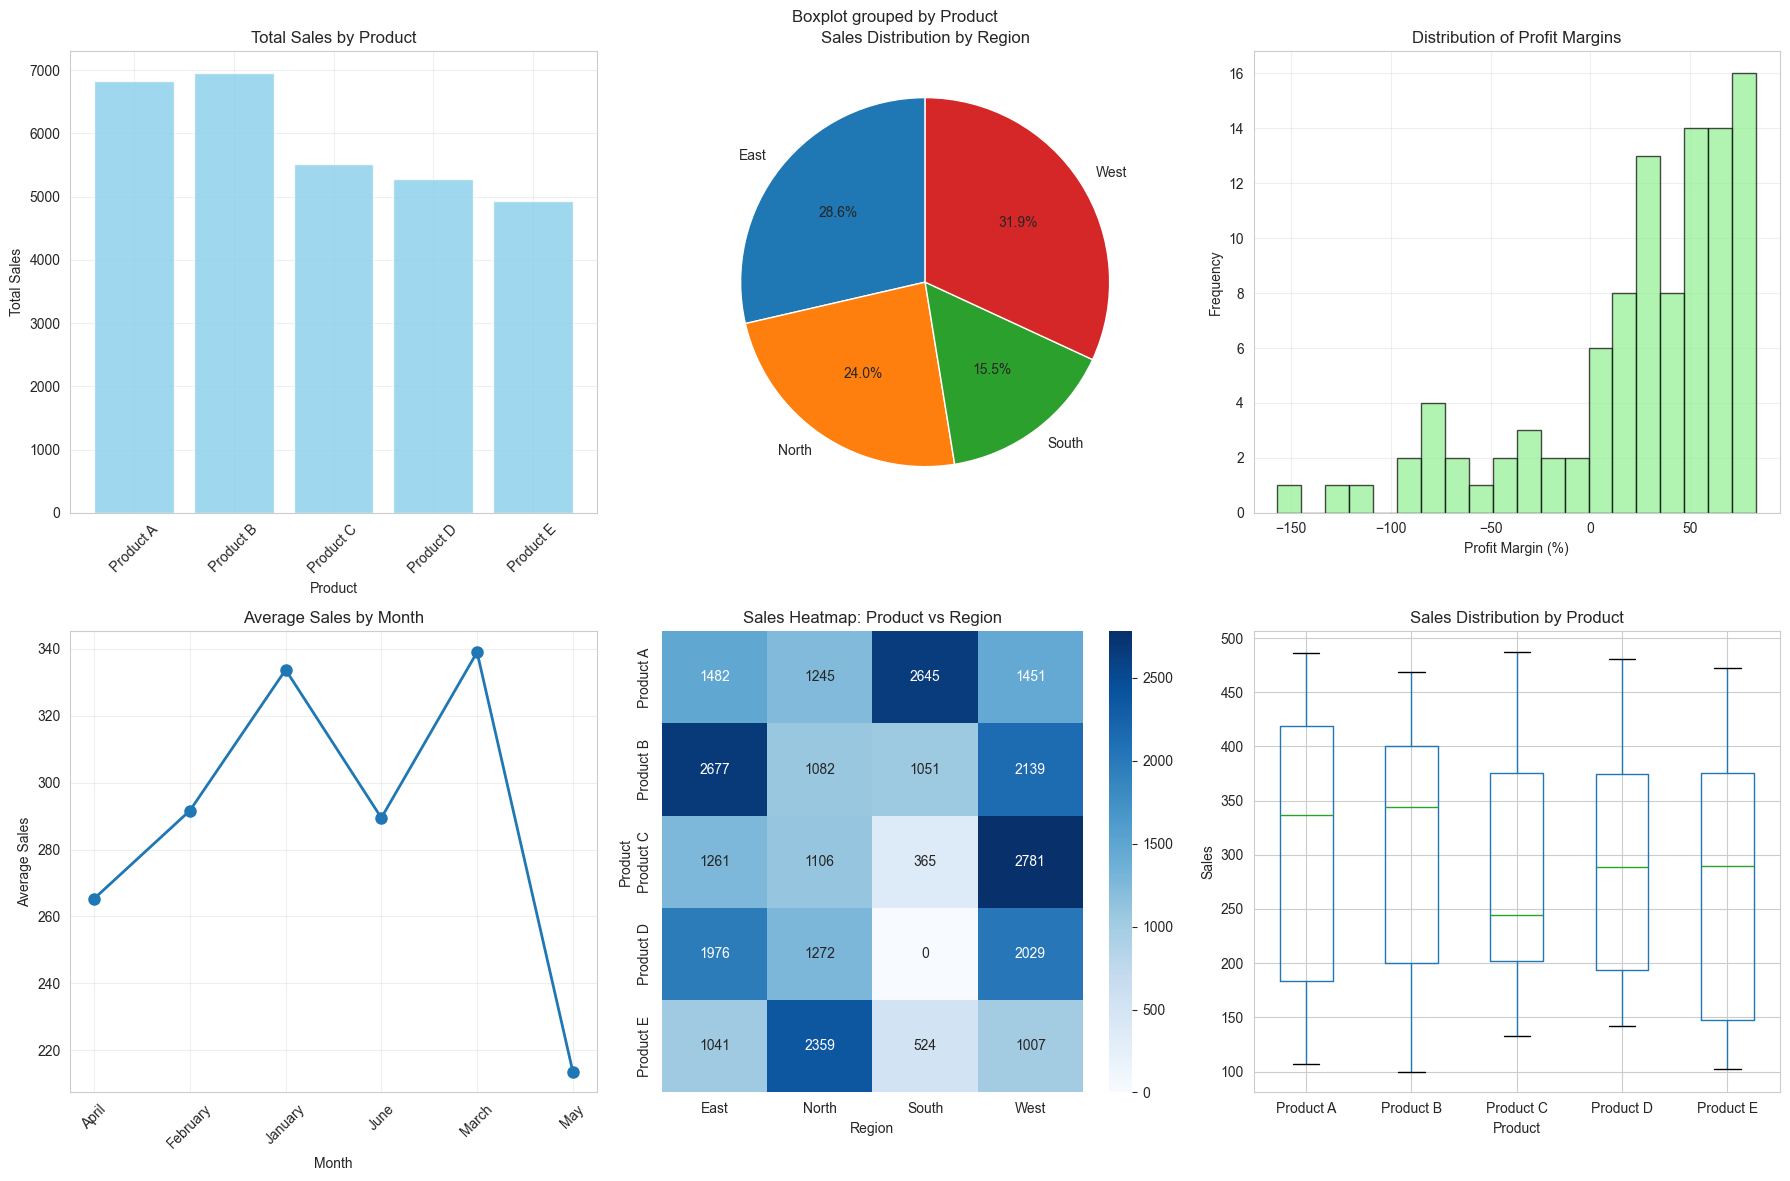


8. Performance Metrics and Rankings:
---------------------------------------------
Salesperson performance metrics:
             Total_Sales  Avg_Sales  Transactions  Total_Profit  \
Salesperson                                                       
Diana               6912     300.52            23          3055   
Charlie             6426     321.30            20          3132   
Bob                 6125     278.41            22          2112   
Eve                 5249     308.76            17          2300   
Alice               4781     265.61            18          1041   

             Avg_Profit_Margin  
Salesperson                     
Diana                    34.72  
Charlie                  42.11  
Bob                      12.67  
Eve                      31.25  
Alice                     2.11  

Product performance ranking:
           Sales  Profit  Profit_Margin  Sales_Rank  Profit_Rank
Product                                                         
Product B   6949    22

In [5]:
print("Exercise 4 - Pandas Data Aggregation:")
print("Advanced grouping and aggregation techniques")
print("-" * 50)

#   initial DataFrame 
data = {
    'Product': ['Product A', 'Product B', 'Product C', 'Product A', 'Product B'],
    'Sales': [200, 150, 300, 250, 180],
    'Month': ['January', 'February', 'March', 'April', 'May']
}
df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)
print(f"DataFrame shape: {df.shape}")

# Expand the dataset for more comprehensive analysis
np.random.seed(200)

# Create a larger dataset
expanded_data = {
    'Product': np.random.choice(['Product A', 'Product B', 'Product C', 'Product D', 'Product E'], 100),
    'Sales': np.random.randint(100, 500, 100),
    'Month': np.random.choice(['January', 'February', 'March', 'April', 'May', 'June'], 100),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'Salesperson': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'], 100),
    'Cost': np.random.randint(50, 300, 100)
}

df_expanded = pd.DataFrame(expanded_data)
df_expanded['Profit'] = df_expanded['Sales'] - df_expanded['Cost']
df_expanded['Profit_Margin'] = (df_expanded['Profit'] / df_expanded['Sales']) * 100

print(f"\nExpanded DataFrame for comprehensive analysis:")
print(f"Shape: {df_expanded.shape}")
print(df_expanded.head(10))

print(f"\n1. Basic Grouping and Aggregation:")
print("-" * 40)

#  grouping by Product
product_summary = df_expanded.groupby('Product').agg({
    'Sales': ['sum', 'mean', 'count', 'std'],
    'Profit': ['sum', 'mean'],
    'Profit_Margin': ['mean', 'min', 'max']
}).round(2)

print("Sales summary by Product:")
print(product_summary)

# Grouping by multiple columns
print(f"\n2. Multi-level Grouping:")
print("-" * 30)

region_product_summary = df_expanded.groupby(['Region', 'Product']).agg({
    'Sales': 'sum',
    'Profit': 'mean',
    'Cost': 'mean'
}).round(2)

print("Sales summary by Region and Product:")
print(region_product_summary.head(10))

print(f"\n3. Advanced Aggregation Functions:")
print("-" * 40)

# Custom aggregation functions
def sales_range(x):
    return x.max() - x.min()

def top_quartile_mean(x):
    return x.quantile(0.75)

custom_agg = df_expanded.groupby('Product').agg({
    'Sales': ['mean', sales_range, top_quartile_mean],
    'Profit': ['sum', 'std'],
    'Profit_Margin': ['median', lambda x: x.quantile(0.25)]
}).round(2)

print("Custom aggregation functions:")
print(custom_agg)

print(f"\n4. Pivot Tables:")
print("-" * 20)

# Create pivot table
pivot_sales = df_expanded.pivot_table(
    values='Sales',
    index='Product',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)

print("Sales pivot table (Product vs Region):")
print(pivot_sales)

# Multi-value pivot table
pivot_multi = df_expanded.pivot_table(
    values=['Sales', 'Profit'],
    index='Product',
    columns='Month',
    aggfunc='mean',
    fill_value=0
).round(2)

print(f"\nMulti-value pivot table (Sales and Profit by Product and Month):")
print(pivot_multi.head())

print(f"\n5. Cross-tabulation:")
print("-" * 25)

# Cross-tabulation
crosstab = pd.crosstab(
    df_expanded['Product'],
    df_expanded['Region'],
    values=df_expanded['Sales'],
    aggfunc='mean'
).round(2)

print("Cross-tabulation of average sales:")
print(crosstab)

print(f"\n6. Advanced Filtering and Aggregation:")
print("-" * 45)

# Conditional aggregation
high_profit_products = df_expanded[df_expanded['Profit_Margin'] > 30].groupby('Product').agg({
    'Sales': 'sum',
    'Profit_Margin': 'mean'
}).round(2)

print("High profit margin products (>30%):")
print(high_profit_products)

# Top performers by region
top_performers = df_expanded.groupby('Region').apply(
    lambda x: x.nlargest(3, 'Sales')[['Product', 'Sales', 'Salesperson']]
).reset_index(drop=True)

print(f"\nTop 3 sales by region:")
print(top_performers.head(12))

print(f"\n7. Statistical Aggregations:")
print("-" * 35)

# Comprehensive statistical summary
stats_summary = df_expanded.groupby('Product').agg({
    'Sales': ['count', 'mean', 'median', 'std', 'min', 'max', 'sum'],
    'Profit_Margin': ['mean', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
}).round(2)

print("Comprehensive statistical summary:")
print(stats_summary)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Sales by Product
product_sales = df_expanded.groupby('Product')['Sales'].sum()
axes[0, 0].bar(product_sales.index, product_sales.values, color='skyblue', alpha=0.8)
axes[0, 0].set_title('Total Sales by Product')
axes[0, 0].set_xlabel('Product')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Sales by Region
region_sales = df_expanded.groupby('Region')['Sales'].sum()
axes[0, 1].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Sales Distribution by Region')

# Plot 3: Profit margin distribution
axes[0, 2].hist(df_expanded['Profit_Margin'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Distribution of Profit Margins')
axes[0, 2].set_xlabel('Profit Margin (%)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Sales by Month
month_sales = df_expanded.groupby('Month')['Sales'].mean()
axes[1, 0].plot(month_sales.index, month_sales.values, marker='o', linewidth=2, markersize=8)
axes[1, 0].set_title('Average Sales by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Sales')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Heatmap of pivot table
sns.heatmap(pivot_sales, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Sales Heatmap: Product vs Region')

# Plot 6: Box plot of sales by product
df_expanded.boxplot(column='Sales', by='Product', ax=axes[1, 2])
axes[1, 2].set_title('Sales Distribution by Product')
axes[1, 2].set_xlabel('Product')
axes[1, 2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

print(f"\n8. Performance Metrics and Rankings:")
print("-" * 45)

# Calculate performance metrics
performance_metrics = df_expanded.groupby('Salesperson').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': 'sum',
    'Profit_Margin': 'mean'
}).round(2)

performance_metrics.columns = ['Total_Sales', 'Avg_Sales', 'Transactions', 'Total_Profit', 'Avg_Profit_Margin']
performance_metrics = performance_metrics.sort_values('Total_Sales', ascending=False)

print("Salesperson performance metrics:")
print(performance_metrics)

# Product performance ranking
product_ranking = df_expanded.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit_Margin': 'mean'
}).round(2)

product_ranking['Sales_Rank'] = product_ranking['Sales'].rank(ascending=False)
product_ranking['Profit_Rank'] = product_ranking['Profit'].rank(ascending=False)
product_ranking = product_ranking.sort_values('Sales', ascending=False)

print(f"\nProduct performance ranking:")
print(product_ranking)

print(f"\n9. Advanced Aggregation Summary:")
print("-" * 40)

total_sales = df_expanded['Sales'].sum()
total_profit = df_expanded['Profit'].sum()
avg_margin = df_expanded['Profit_Margin'].mean()
best_product = product_ranking.index[0]
best_region = region_sales.idxmax()

print(f"Business Summary:")
print(f"• Total Sales: {total_sales:,} units")
print(f"• Total Profit: {total_profit:,} units")
print(f"• Average Profit Margin: {avg_margin:.2f}%")
print(f"• Best Performing Product: {best_product}")
print(f"• Best Performing Region: {best_region}")
print(f"• Number of Transactions: {len(df_expanded)}")

print(f"\nKey Aggregation Techniques Demonstrated:")
print("• Basic groupby with multiple aggregation functions")
print("• Multi-level grouping and hierarchical indexing")
print("• Custom aggregation functions")
print("• Pivot tables for cross-tabular analysis")
print("• Conditional aggregation and filtering")
print("• Statistical summaries and percentiles")
print("• Performance ranking and metrics calculation")

## Exercise 5: Complex Data Visualization



Exercise 5 - Complex Data Visualization:
Creating advanced multi-plot layouts with different chart types
----------------------------------------------------------------------
Generated datasets:
• Time series: 365 daily stock prices
• Categorical: 6 industry sectors
• Scatter plot: 200 data points with relationships
• Distributions: 4 different statistical distributions
• 3D surface: (50, 50) grid points


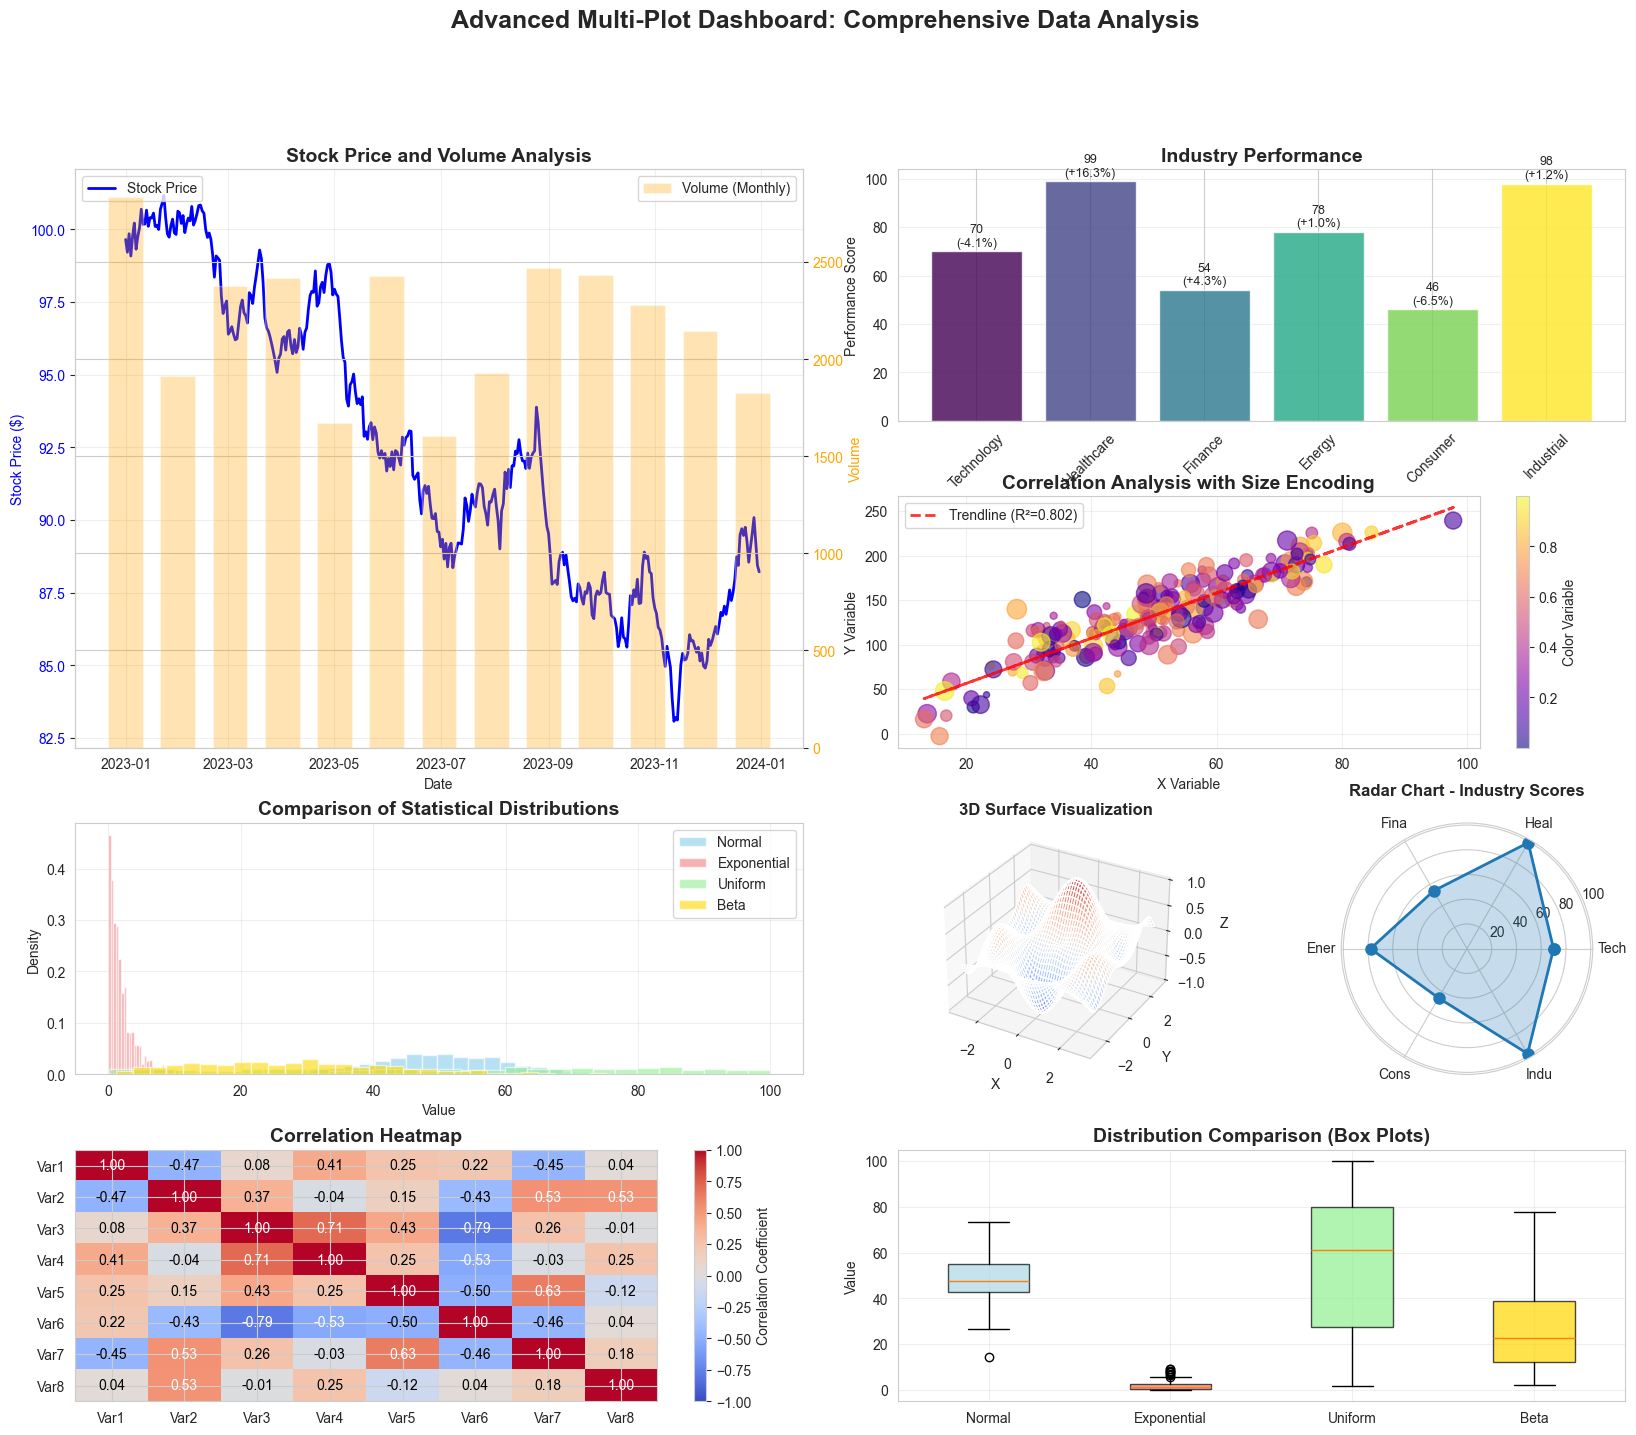


Advanced Statistical Visualization Dashboard:
--------------------------------------------------


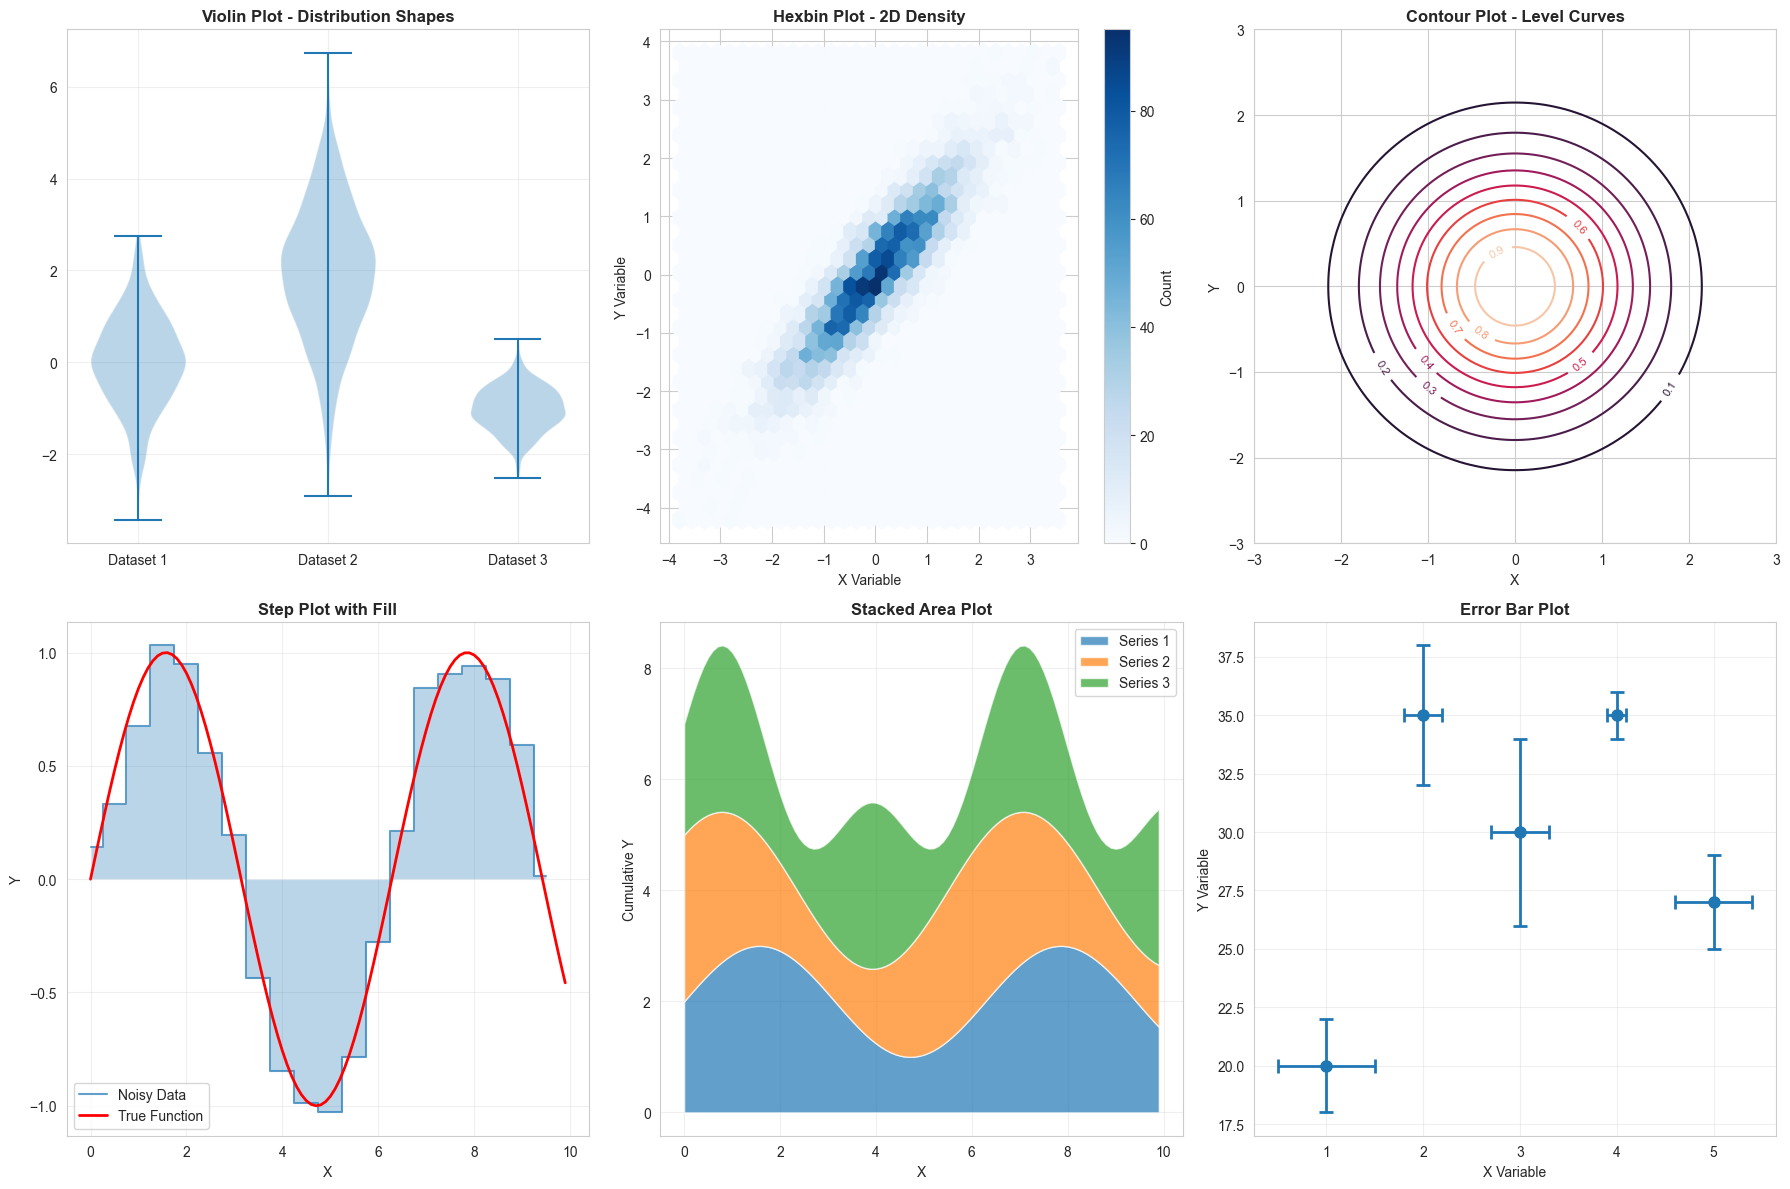


Visualization Techniques Demonstrated:
  • 1. Time Series with Dual Y-Axes
  • 2. Categorical Bar Charts with Annotations
  • 3. Enhanced Scatter Plots with Size and Color Encoding
  • 4. Multiple Distribution Overlays
  • 5. 3D Surface Plots
  • 6. Polar/Radar Charts
  • 7. Correlation Heatmaps with Text Labels
  • 8. Box Plot Comparisons
  • 9. Violin Plots for Distribution Shapes
  • 10. Hexbin Plots for 2D Density
  • 11. Contour Plots with Level Labels
  • 12. Step Plots with Fill Areas
  • 13. Stacked Area Charts
  • 14. Error Bar Plots with Uncertainties

Key Design Principles Applied:
-----------------------------------
• Complex grid layouts using GridSpec
• Consistent color schemes and styling
• Appropriate chart selection for data types
• Multiple encoding channels (position, color, size)
• Professional annotations and labels
• Interactive elements (colorbars, legends)
• Efficient use of subplot space
• Clear visual hierarchy and readability

Advanced Features Used:
-------

In [6]:
print("Exercise 5 - Complex Data Visualization:")
print("Creating advanced multi-plot layouts with different chart types")
print("-" * 70)

# Generate comprehensive datasets for visualization
np.random.seed(250)

# Dataset 1: Time series data
dates = pd.date_range('2023-01-01', periods=365, freq='D')
stock_prices = 100 + np.cumsum(np.random.randn(365) * 0.5)
volume = np.random.poisson(1000, 365) + np.random.randint(500, 2000, 365)

# Dataset 2: Categorical data
categories = ['Technology', 'Healthcare', 'Finance', 'Energy', 'Consumer', 'Industrial']
values = np.random.randint(20, 100, len(categories))
growth_rates = np.random.normal(5, 10, len(categories))

# Dataset 3: Scatter plot data with relationships
n_points = 200
x_scatter = np.random.normal(50, 15, n_points)
y_scatter = 2.5 * x_scatter + np.random.normal(0, 20, n_points) + 10
sizes = np.random.randint(20, 200, n_points)
colors = np.random.rand(n_points)

# Dataset 4: Distribution data
dist_data = {
    'Normal': np.random.normal(50, 10, 1000),
    'Exponential': np.random.exponential(2, 1000),
    'Uniform': np.random.uniform(0, 100, 1000),
    'Beta': np.random.beta(2, 5, 1000) * 100
}

# Dataset 5: 3D surface data
x_3d = np.linspace(-3, 3, 50)
y_3d = np.linspace(-3, 3, 50)
X_3d, Y_3d = np.meshgrid(x_3d, y_3d)
Z_3d = np.sin(np.sqrt(X_3d**2 + Y_3d**2)) * np.cos(X_3d) * np.sin(Y_3d)

print("Generated datasets:")
print(f"• Time series: {len(stock_prices)} daily stock prices")
print(f"• Categorical: {len(categories)} industry sectors")
print(f"• Scatter plot: {n_points} data points with relationships")
print(f"• Distributions: {len(dist_data)} different statistical distributions")
print(f"• 3D surface: {X_3d.shape} grid points")

# Create the main complex visualization
fig = plt.figure(figsize=(20, 16))

# Define a grid layout for complex subplot arrangement
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# 1. Time Series Line Plot with Volume (spans 2x2)
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax1_twin = ax1.twinx()

# Stock price line
line1 = ax1.plot(dates, stock_prices, color='blue', linewidth=2, label='Stock Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Volume bars
bars = ax1_twin.bar(dates[::30], volume[::30], alpha=0.3, color='orange', width=20, label='Volume (Monthly)')
ax1_twin.set_ylabel('Volume', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')

ax1.set_title('Stock Price and Volume Analysis', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Categorical Bar Chart with Growth Rates (top right)
ax2 = fig.add_subplot(gs[0, 2:])
bars = ax2.bar(categories, values, color=plt.cm.viridis(np.linspace(0, 1, len(categories))), alpha=0.8)
ax2.set_title('Industry Performance', fontsize=14, fontweight='bold')
ax2.set_xlabel('Industry Sector')
ax2.set_ylabel('Performance Score')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value, growth in zip(bars, values, growth_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value}\n({growth:+.1f}%)', ha='center', va='bottom', fontsize=9)

ax2.grid(True, alpha=0.3, axis='y')

# 3. Enhanced Scatter Plot 
ax3 = fig.add_subplot(gs[1, 2:])
scatter = ax3.scatter(x_scatter, y_scatter, c=colors, s=sizes, alpha=0.6, cmap='plasma')
ax3.set_title('Correlation Analysis with Size Encoding', fontsize=14, fontweight='bold')
ax3.set_xlabel('X Variable')
ax3.set_ylabel('Y Variable')

# Add trendline
z = np.polyfit(x_scatter, y_scatter, 1)
p = np.poly1d(z)
ax3.plot(x_scatter, p(x_scatter), "r--", alpha=0.8, linewidth=2, label=f'Trendline (R²={np.corrcoef(x_scatter, y_scatter)[0,1]**2:.3f})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Color Variable')

# 4. Multiple Distribution Histograms 
ax4 = fig.add_subplot(gs[2, 0:2])
colors_dist = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
for i, (name, data) in enumerate(dist_data.items()):
    ax4.hist(data, bins=30, alpha=0.6, label=name, color=colors_dist[i], density=True)

ax4.set_title('Comparison of Statistical Distributions', fontsize=14, fontweight='bold')
ax4.set_xlabel('Value')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. 3D Surface Plot (bottom middle)
ax5 = fig.add_subplot(gs[2, 2], projection='3d')
surf = ax5.plot_surface(X_3d, Y_3d, Z_3d, cmap='coolwarm', alpha=0.8)
ax5.set_title('3D Surface Visualization', fontsize=12, fontweight='bold')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')

# 6. Polar Plot 
ax6 = fig.add_subplot(gs[2, 3], projection='polar')
theta = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
theta = np.concatenate((theta, [theta[0]]))  
values_polar = np.concatenate((values, [values[0]]))

ax6.plot(theta, values_polar, 'o-', linewidth=2, markersize=8)
ax6.fill(theta, values_polar, alpha=0.25)
ax6.set_title('Radar Chart - Industry Scores', fontsize=12, fontweight='bold', pad=20)
ax6.set_xticks(theta[:-1])
ax6.set_xticklabels([cat[:4] for cat in categories])

# 7. Heatmap 
ax7 = fig.add_subplot(gs[3, 0:2])
correlation_matrix = np.random.randn(8, 8)
correlation_matrix = np.corrcoef(correlation_matrix)

im = ax7.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax7.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Add correlation values as text
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        ax7.text(j, i, f'{correlation_matrix[i, j]:.2f}', 
                ha='center', va='center', color='white' if abs(correlation_matrix[i, j]) > 0.5 else 'black')

ax7.set_xticks(range(8))
ax7.set_yticks(range(8))
ax7.set_xticklabels([f'Var{i+1}' for i in range(8)])
ax7.set_yticklabels([f'Var{i+1}' for i in range(8)])

# Add colorbar
cbar = plt.colorbar(im, ax=ax7)
cbar.set_label('Correlation Coefficient')

# 8. Box Plot Comparison 
ax8 = fig.add_subplot(gs[3, 2:])
box_data = [dist_data['Normal'][:100], dist_data['Exponential'][:100], 
            dist_data['Uniform'][:100], dist_data['Beta'][:100]]
box_labels = ['Normal', 'Exponential', 'Uniform', 'Beta']

bp = ax8.boxplot(box_data, labels=box_labels, patch_artist=True)
ax8.set_title('Distribution Comparison (Box Plots)', fontsize=14, fontweight='bold')
ax8.set_ylabel('Value')

# Color the box plots
colors_box = ['lightblue', 'lightcoral', 'lightgreen', 'gold']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax8.grid(True, alpha=0.3)

plt.suptitle('Advanced Multi-Plot Dashboard: Comprehensive Data Analysis', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# Create a second visualization focusing on advanced statistical plots
print(f"\nAdvanced Statistical Visualization Dashboard:")
print("-" * 50)

fig2, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Violin Plot
data_violin = [np.random.normal(0, 1, 1000), 
               np.random.normal(2, 1.5, 1000), 
               np.random.normal(-1, 0.5, 1000)]
parts = axes[0, 0].violinplot(data_violin, positions=[1, 2, 3])
axes[0, 0].set_title('Violin Plot - Distribution Shapes', fontweight='bold')
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].set_xticklabels(['Dataset 1', 'Dataset 2', 'Dataset 3'])
axes[0, 0].grid(True, alpha=0.3)

# 2. Hexbin Plot 
x_hex = np.random.normal(0, 1, 5000)
y_hex = x_hex + np.random.normal(0, 0.5, 5000)
hb = axes[0, 1].hexbin(x_hex, y_hex, gridsize=30, cmap='Blues')
axes[0, 1].set_title('Hexbin Plot - 2D Density', fontweight='bold')
axes[0, 1].set_xlabel('X Variable')
axes[0, 1].set_ylabel('Y Variable')
cb = plt.colorbar(hb, ax=axes[0, 1])
cb.set_label('Count')

# 3. Contour Plot
x_cont = np.linspace(-3, 3, 100)
y_cont = np.linspace(-3, 3, 100)
X_cont, Y_cont = np.meshgrid(x_cont, y_cont)
Z_cont = np.exp(-(X_cont**2 + Y_cont**2)/2)

cs = axes[0, 2].contour(X_cont, Y_cont, Z_cont, levels=10)
axes[0, 2].clabel(cs, inline=True, fontsize=8)
axes[0, 2].set_title('Contour Plot - Level Curves', fontweight='bold')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')

# 4. Step Plot
x_step = np.arange(0, 10, 0.1)
y_step = np.sin(x_step) + np.random.normal(0, 0.1, len(x_step))
y_step_smooth = np.sin(x_step)

axes[1, 0].step(x_step[::5], y_step[::5], where='mid', label='Noisy Data', alpha=0.7)
axes[1, 0].plot(x_step, y_step_smooth, 'r-', label='True Function', linewidth=2)
axes[1, 0].fill_between(x_step[::5], y_step[::5], step='mid', alpha=0.3)
axes[1, 0].set_title('Step Plot with Fill', fontweight='bold')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Stacked Area Plot
x_area = np.arange(0, 10, 0.1)
y1 = np.sin(x_area) + 2
y2 = np.cos(x_area) + 2
y3 = np.sin(2*x_area) + 2

axes[1, 1].fill_between(x_area, 0, y1, alpha=0.7, label='Series 1')
axes[1, 1].fill_between(x_area, y1, y1+y2, alpha=0.7, label='Series 2')
axes[1, 1].fill_between(x_area, y1+y2, y1+y2+y3, alpha=0.7, label='Series 3')
axes[1, 1].set_title('Stacked Area Plot', fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Cumulative Y')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Error Bar Plot
x_err = np.arange(1, 6)
y_err = [20, 35, 30, 35, 27]
yerr = [2, 3, 4, 1, 2]
xerr = [0.5, 0.2, 0.3, 0.1, 0.4]

axes[1, 2].errorbar(x_err, y_err, yerr=yerr, xerr=xerr, fmt='o', capsize=5, 
                   capthick=2, markersize=8, linewidth=2)
axes[1, 2].set_title('Error Bar Plot', fontweight='bold')
axes[1, 2].set_xlabel('X Variable')
axes[1, 2].set_ylabel('Y Variable')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisualization Techniques Demonstrated:")
print("="*50)

techniques = [
    "1. Time Series with Dual Y-Axes",
    "2. Categorical Bar Charts with Annotations",
    "3. Enhanced Scatter Plots with Size and Color Encoding",
    "4. Multiple Distribution Overlays",
    "5. 3D Surface Plots",
    "6. Polar/Radar Charts", 
    "7. Correlation Heatmaps with Text Labels",
    "8. Box Plot Comparisons",
    "9. Violin Plots for Distribution Shapes",
    "10. Hexbin Plots for 2D Density",
    "11. Contour Plots with Level Labels",
    "12. Step Plots with Fill Areas",
    "13. Stacked Area Charts",
    "14. Error Bar Plots with Uncertainties"
]

for technique in techniques:
    print(f"  • {technique}")

print(f"\nKey Design Principles Applied:")
print("-" * 35)
print("• Complex grid layouts using GridSpec")
print("• Consistent color schemes and styling")
print("• Appropriate chart selection for data types")
print("• Multiple encoding channels (position, color, size)")
print("• Professional annotations and labels")
print("• Interactive elements (colorbars, legends)")
print("• Efficient use of subplot space")
print("• Clear visual hierarchy and readability")

print(f"\nAdvanced Features Used:")
print("-" * 25)
print("• Twin axes for multiple scales")
print("• 3D projections and surface rendering")
print("• Polar coordinate systems")
print("• Custom colormaps and transparency")
print("• Mathematical function overlays")
print("• Statistical trend lines and correlations")
print("• Dynamic text positioning")
print("• Multi-level subplot arrangements")